# Trabajo 1: Análisis geodemográfico del Gran Santiago

**Estudiante:** Matilda Concha Miño  
**Asignatura:** Modelación de Datos Geodemográficos  
**Fuente principal:** Censo de Población y Vivienda 2017 (INE)  
**Unidad de análisis:** comunas y zonas censales urbanas

Este notebook calcula y compara tres indicadores: población de 0 a 17 años, población de 65 años o más y viviendas con hacinamiento. Todo el flujo -restauración de PostgreSQL/PostGIS, consultas SQL, controles, tablas, gráficos, mapas e interpretación- queda documentado y ejecutable en orden.

## 1. Introducción y área de estudio

El análisis geodemográfico permite estudiar cómo se distribuyen las características de la población y de las viviendas en el territorio. En este trabajo se analiza el **Gran Santiago**, definido operacionalmente como las 32 comunas de la provincia de Santiago más Puente Alto y San Bernardo, es decir, 34 comunas.

La delimitación reúne el núcleo continuo de la metrópolis y sectores centrales y periféricos con estructuras demográficas y condiciones habitacionales diversas. La comparación entre comunas resume los patrones generales; la zona censal permite observar diferencias internas que el promedio comunal puede ocultar.

La fuente es la base PostgreSQL del Censo 2017 entregada en el curso. El Censo 2017 fue un operativo abreviado y de hecho; por ello, este análisis es una fotografía territorial de 2017 y no una explicación causal ni una medición actual.

## 2. Objetivos

### Objetivo general

Analizar la distribución espacial y la relación entre indicadores de estructura etaria y hacinamiento en las comunas y zonas censales urbanas del Gran Santiago, utilizando SQL, Python y datos del Censo 2017.

### Objetivos específicos

1. Calcular tres indicadores comparables territorialmente a nivel comunal y de zona censal.
2. Describir su distribución mediante tablas, estadísticos, histogramas, gráficos y mapas temáticos.
3. Identificar unidades con valores altos y bajos, controlando el tamaño de sus denominadores.
4. Comparar patrones y correlaciones entre la escala comunal y la zona censal.
5. Interpretar los resultados considerando estructura demográfica, desigualdad territorial, MAUP y límites del análisis ecológico.

## 3. Metodología resumida

1. Se restaura el respaldo del curso en PostgreSQL 17 con PostGIS 3.
2. Se inspeccionan tablas, columnas, categorías y claves antes de consultar.
3. Los indicadores etarios se agregan desde `personas`; el hacinamiento se agrega separadamente desde `viviendas`. Esta separación evita multiplicar viviendas al unirlas con personas.
4. Los resultados se unen por `codigo_comuna` o `geocodigo` y luego con la geometría correspondiente.
5. Se validan rangos, nulos, duplicados, denominadores, cardinalidad de uniones, geometrías y CRS.
6. Se usan cinco cuantiles cuando los datos permiten cinco clases distintas; de lo contrario, el código cambia a intervalos iguales y lo informa.
7. Las correlaciones son de Pearson y se interpretan como asociaciones territoriales, no como causalidad ni relaciones individuales.

## 4. Entorno reproducible: Python, PostgreSQL y PostGIS

La celda siguiente instala únicamente bibliotecas Python ausentes. En Colab, PostgreSQL/PostGIS se instala después mediante el procedimiento usado en clases. En una ejecución local de verificación se puede definir `MDG_DB_HOST`, `MDG_DB_PORT`, `MDG_DB_NAME` y `MDG_DB_USER`.

In [1]:
import importlib.util
import os
import sys
import subprocess
import shutil
import secrets
from pathlib import Path

try:
    import google.colab  # disponible únicamente dentro de Colab
    IN_COLAB = True
except ModuleNotFoundError:
    IN_COLAB = False

required_python = {
    "geopandas": "geopandas",
    "sqlalchemy": "sqlalchemy",
    "psycopg2": "psycopg2-binary",
    "mapclassify": "mapclassify",
    "seaborn": "seaborn",
    "scipy": "scipy",
    "adjustText": "adjustText",
}
missing = [package for module, package in required_python.items()
           if importlib.util.find_spec(module) is None]
if missing:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import seaborn as sns
from adjustText import adjust_text
from IPython.display import display
from IPython import get_ipython
from sqlalchemy import create_engine, text
from sqlalchemy.engine import URL

get_ipython().run_line_magic("matplotlib", "inline")
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 30)
print(f"Entorno: {'Google Colab' if IN_COLAB else 'local'}")
print("Bibliotecas Python disponibles.")

Entorno: local
Bibliotecas Python disponibles.


### 4.1 Ubicación del respaldo

Por defecto, Colab espera el archivo en `/content/censo_rm_v2.backup`, como en el procedimiento de clases. Si está en Google Drive, cambia `USE_GOOGLE_DRIVE` a `True` y escribe la ruta real en `DRIVE_BACKUP_PATH`. No se inventa una ruta definitiva.

> El montaje de Drive requiere autorización interactiva de la cuenta de Google.

In [2]:
USE_GOOGLE_DRIVE = False
DRIVE_BACKUP_PATH = "/content/drive/MyDrive/REEMPLAZAR/censo_rm_v2.backup"
FORCE_RESTORE = False

if IN_COLAB:
    if USE_GOOGLE_DRIVE:
        from google.colab import drive
        drive.mount("/content/drive")
        BACKUP_PATH = Path(DRIVE_BACKUP_PATH)
    else:
        BACKUP_PATH = Path("/content/censo_rm_v2.backup")
else:
    BACKUP_PATH = Path(os.environ.get(
        "MDG_BACKUP_PATH",
        r"C:\Users\matil\OneDrive\Desktop\MDG\T1 Lab\BACKUP\censo_rm_v2.backup"
    ))

DB_NAME = "censo_rm_2017" if IN_COLAB else os.environ.get("MDG_DB_NAME", "censo_rm_2017")
print(f"Respaldo configurado: {BACKUP_PATH}")
print("FORCE_RESTORE =", FORCE_RESTORE)

Respaldo configurado: C:\Users\matil\OneDrive\Desktop\MDG\T1 Lab\BACKUP\censo_rm_v2.backup
FORCE_RESTORE = False


### 4.2 Instalación y restauración de PostgreSQL/PostGIS

La celda es idempotente: no reinstala PostgreSQL 17 si ya existe y no restaura la base si las tablas requeridas ya están cargadas, salvo que `FORCE_RESTORE=True`. La contraseña local se genera en memoria y no se imprime ni se guarda en el notebook.

In [3]:
def run_checked(command, *, shell=False):
    result = subprocess.run(
        command, shell=shell, text=True,
        stdout=subprocess.PIPE, stderr=subprocess.STDOUT
    )
    if result.returncode != 0:
        tail = result.stdout[-2500:] if result.stdout else "sin salida"
        raise RuntimeError(f"Falló el comando: {command}\n{tail}")
    return result.stdout


if IN_COLAB:
    pg_restore_17 = Path("/usr/lib/postgresql/17/bin/pg_restore")
    if not pg_restore_17.exists():
        print("Instalando PostgreSQL 17, cliente y PostGIS 3...")
        run_checked("sudo apt-get update -qq", shell=True)
        run_checked("sudo DEBIAN_FRONTEND=noninteractive apt-get install -y -qq curl ca-certificates postgresql-common", shell=True)
        run_checked("sudo install -d /usr/share/postgresql-common/pgdg", shell=True)
        run_checked("sudo curl --fail -sS -o /usr/share/postgresql-common/pgdg/apt.postgresql.org.asc https://www.postgresql.org/media/keys/ACCC4CF8.asc", shell=True)
        run_checked("bash -c 'echo \"deb [signed-by=/usr/share/postgresql-common/pgdg/apt.postgresql.org.asc] https://apt.postgresql.org/pub/repos/apt $(. /etc/os-release && echo ${VERSION_CODENAME})-pgdg main\" | sudo tee /etc/apt/sources.list.d/pgdg.list >/dev/null'", shell=True)
        run_checked("sudo apt-get update -qq", shell=True)
        run_checked("sudo DEBIAN_FRONTEND=noninteractive apt-get install -y -qq postgresql-17 postgresql-client-17 postgresql-17-postgis-3", shell=True)
    else:
        print("PostgreSQL 17 ya está instalado; se omite la reinstalación.")

    clusters = run_checked(["pg_lsclusters"])
    if not any("17" in line and "main" in line and "online" in line for line in clusters.splitlines()):
        run_checked(["sudo", "pg_ctlcluster", "17", "main", "start"])
    clusters = run_checked(["pg_lsclusters"])
    assert any("17" in line and "main" in line and "online" in line for line in clusters.splitlines())
    print("PostgreSQL 17 está en línea.")

    if not BACKUP_PATH.is_file():
        raise FileNotFoundError(
            f"No se encontró {BACKUP_PATH}. Sube el respaldo a /content o configura la ruta de Drive."
        )
    run_checked([str(pg_restore_17), "--list", str(BACKUP_PATH)])
    print(f"Respaldo PostgreSQL válido ({BACKUP_PATH.stat().st_size / 1024**2:.1f} MB).")

    db_exists = run_checked([
        "sudo", "-u", "postgres", "psql", "-tAc",
        f"SELECT 1 FROM pg_database WHERE datname='{DB_NAME}'"
    ]).strip() == "1"
    tables_ok = False
    if db_exists and not FORCE_RESTORE:
        tables_ok = run_checked([
            "sudo", "-u", "postgres", "psql", "-d", DB_NAME, "-tAc",
            "SELECT (to_regclass('public.personas') IS NOT NULL AND to_regclass('dpa.zonas_censales_rm') IS NOT NULL)::int"
        ]).strip() == "1"

    if FORCE_RESTORE or not (db_exists and tables_ok):
        run_checked(["sudo", "-u", "postgres", "dropdb", "--if-exists", DB_NAME])
        run_checked(["sudo", "-u", "postgres", "createdb", "--template=template0", "--encoding=UTF8", DB_NAME])
        run_checked([
            "sudo", "-u", "postgres", str(pg_restore_17),
            f"--dbname={DB_NAME}", "--no-owner", "--no-privileges", "--jobs=2",
            str(BACKUP_PATH)
        ])
        print("Base restaurada correctamente.")
    else:
        print("La base ya contiene las tablas requeridas; se omite la restauración.")

    DB_USER = "postgres"
    DB_PASSWORD = secrets.token_hex(20)
    run_checked([
        "sudo", "-u", "postgres", "psql", "-q", "-c",
        f"ALTER USER postgres PASSWORD '{DB_PASSWORD}';"
    ])
    connection_url = URL.create(
        "postgresql+psycopg2", username=DB_USER, password=DB_PASSWORD,
        host="localhost", port=5432, database=DB_NAME
    )
else:
    DB_USER = os.environ.get("MDG_DB_USER", os.environ.get("USERNAME", "postgres"))
    connection_url = URL.create(
        "postgresql+psycopg2",
        username=DB_USER,
        password=os.environ.get("MDG_DB_PASSWORD") or None,
        host=os.environ.get("MDG_DB_HOST", "localhost"),
        port=int(os.environ.get("MDG_DB_PORT", "5432")),
        database=DB_NAME,
    )

engine = create_engine(connection_url)
with engine.connect() as connection:
    verification = pd.read_sql(text('''
        SELECT current_database() AS base,
               current_setting('server_version') AS postgresql,
               postgis_version() AS postgis
    '''), connection)
display(verification)
print("Conexión y PostGIS verificados.")

,base,postgresql,postgis
0,censo_rm_audit_20260811,17.10,3.6 USE_GEOS=1 USE_PROJ=1 USE_STATS=1


Conexión y PostGIS verificados.


## 5. Auditoría del esquema, diccionario y uniones

Antes de calcular se confirman las tablas, columnas, códigos y claves. El respaldo contiene `variables` y `variables_codificacion`, que funcionan como diccionario interno. Los controles también comprueban que las uniones no multipliquen registros.

In [4]:
required = {
    "personas": {"persona_ref_id", "hogar_ref_id", "p09"},
    "hogares": {"hogar_ref_id", "vivienda_ref_id"},
    "viviendas": {"vivienda_ref_id", "zonaloc_ref_id", "p01", "p02", "ind_hacin", "ind_hacin_rec"},
    "zonas": {"zonaloc_ref_id", "geocodigo", "codigo_comuna"},
    "comunas": {"codigo_comuna", "nom_comuna", "provincia_ref_id"},
    "provincias": {"provincia_ref_id", "nom_provincia"},
}

schema = pd.read_sql('''
    SELECT table_schema, table_name, column_name, data_type
    FROM information_schema.columns
    WHERE table_schema IN ('public', 'dpa')
    ORDER BY table_schema, table_name, ordinal_position
''', engine)
for table_name, columns in required.items():
    found = set(schema.loc[(schema.table_schema == "public") &
                           (schema.table_name == table_name), "column_name"])
    missing_columns = columns - found
    assert not missing_columns, f"Faltan columnas en {table_name}: {sorted(missing_columns)}"

dictionary = pd.read_sql('''
    SELECT tabla, variable, descripcion, tipo, rango
    FROM public.variables
    WHERE (tabla='personas' AND variable='p09')
       OR (tabla='viviendas' AND variable IN ('p01','p02','ind_hacin','ind_hacin_rec'))
    ORDER BY tabla, variable
''', engine)
codes = pd.read_sql('''
    SELECT tabla, variable, valor, descripcion
    FROM public.variables_codificacion
    WHERE (tabla='personas' AND variable='p09' AND valor >= 100)
       OR (tabla='viviendas' AND variable IN ('p01','p02','ind_hacin','ind_hacin_rec'))
    ORDER BY tabla, variable, valor
''', engine)
display(dictionary)
display(codes)

controls = pd.read_sql('''
    SELECT
      (SELECT COUNT(*)-COUNT(DISTINCT persona_ref_id) FROM personas) AS dup_persona,
      (SELECT COUNT(*)-COUNT(DISTINCT hogar_ref_id) FROM hogares) AS dup_hogar,
      (SELECT COUNT(*)-COUNT(DISTINCT vivienda_ref_id) FROM viviendas) AS dup_vivienda,
      (SELECT COUNT(*)-COUNT(DISTINCT zonaloc_ref_id) FROM zonas) AS dup_zona,
      (SELECT COUNT(*)-COUNT(DISTINCT codigo_comuna) FROM comunas) AS dup_comuna,
      (SELECT COUNT(*) FROM personas) AS personas,
      (SELECT COUNT(*) FROM personas p
         JOIN hogares h USING(hogar_ref_id)
         JOIN viviendas v USING(vivienda_ref_id)
         JOIN zonas z USING(zonaloc_ref_id)
         JOIN comunas c USING(codigo_comuna)
         JOIN provincias pr USING(provincia_ref_id)) AS filas_join_personas,
      (SELECT COUNT(*) FROM viviendas
         WHERE ind_hacin_rec BETWEEN 1 AND 4
           AND NOT (p01 BETWEEN 1 AND 7 AND p02=1)) AS hacin_validos_fuera_universo
''', engine)
display(controls)
assert controls.filter(like="dup_").eq(0).all(axis=None)
assert controls.loc[0, "personas"] == controls.loc[0, "filas_join_personas"]
assert controls.loc[0, "hacin_validos_fuera_universo"] == 0

age_check = pd.read_sql('''
    SELECT MIN(p09) AS edad_min, MAX(p09) AS edad_max,
           COUNT(*) FILTER (WHERE p09 IS NULL OR p09 NOT BETWEEN 0 AND 100) AS edad_no_valida
    FROM personas
''', engine)
hacin_check = pd.read_sql('''
    SELECT ind_hacin_rec, COUNT(*) AS viviendas
    FROM viviendas GROUP BY ind_hacin_rec ORDER BY ind_hacin_rec
''', engine)
display(age_check)
display(hacin_check)
assert age_check.loc[0, "edad_no_valida"] == 0
print("Esquema, claves, categorías y cardinalidad de uniones: correctos.")

,tabla,variable,descripcion,tipo,rango
0,personas,p09,Edad,integer,0 - 130
1,viviendas,ind_hacin,Tasa de Hacinamiento,numeric,0 - 999
2,viviendas,ind_hacin_rec,Indice_hacinamiento recodificado/a,integer,1 - 9
3,viviendas,p01,Tipo de Vivienda,integer,1 - 10
4,viviendas,p02,Ocupación de la Vivienda,integer,1 - 4


,tabla,variable,valor,descripcion
0,personas,p09,100,Años y Más
1,personas,p09,131,No Aplica
2,personas,p09,132,Valor Perdido
3,viviendas,ind_hacin,999,Valor Perdido
4,viviendas,ind_hacin_rec,1,Sin Hacinamiento
5,viviendas,ind_hacin_rec,2,Hacinamiento Medio
6,viviendas,ind_hacin_rec,3,Hacinamiento Alto
7,viviendas,ind_hacin_rec,4,Hacinamiento Crítico
8,viviendas,ind_hacin_rec,9,No Aplica
9,viviendas,p01,0,No Aplica


,dup_persona,dup_hogar,dup_vivienda,dup_zona,dup_comuna,personas,filas_join_personas,hacin_validos_fuera_universo
0,0,0,0,0,0,7112808,7112808,0


,edad_min,edad_max,edad_no_valida
0,0,100,0


,ind_hacin_rec,viviendas
0,1,1923109
1,2,116510
2,3,27278
3,4,12464
4,9,299129


Esquema, claves, categorías y cardinalidad de uniones: correctos.


## 6. Definición de los indicadores

### Indicador 1. Porcentaje de población de 0 a 17 años

- **Dimensión:** estructura etaria.
- **Fórmula:** $100\,N(0\leq p09\leq17)/N(0\leq p09\leq100)$.
- **Numerador:** personas de 0 a 17 años.
- **Denominador:** total de personas con edad válida de la unidad territorial.
- **Unidad:** comuna o zona censal urbana.
- **Nulos/sin información:** se excluyen edades nulas o fuera de 0–100. En este respaldo el control demuestra que no existen, por lo que el denominador coincide con el total de personas.
- **Justificación:** describe la presencia relativa de población infantil y adolescente, relevante para servicios educativos, cuidado y equipamientos.

### Indicador 2. Porcentaje de población de 65 años o más

- **Dimensión:** envejecimiento demográfico.
- **Fórmula:** $100\,N(65\leq p09\leq100)/N(0\leq p09\leq100)$.
- **Numerador:** personas de 65 años o más.
- **Denominador:** total de personas con edad válida de la unidad territorial.
- **Unidad:** comuna o zona censal urbana.
- **Nulos/sin información:** igual tratamiento que el indicador 1.
- **Justificación:** aproxima la importancia relativa de la población mayor y permite contrastar estructuras etarias territoriales.

### Indicador 3. Porcentaje de viviendas con hacinamiento

- **Dimensión:** condiciones habitacionales.
- **Fórmula:** $100\,N(ind\_hacin\_rec\in\{2,3,4\})/N(ind\_hacin\_rec\in\{1,2,3,4\})$.
- **Numerador:** viviendas particulares ocupadas con moradores presentes clasificadas con hacinamiento medio, alto o crítico.
- **Denominador:** viviendas particulares ocupadas con moradores presentes y clasificación válida de hacinamiento.
- **Unidad:** comuna o zona censal urbana.
- **Nulos/sin información:** se excluye `ind_hacin_rec=9` (No aplica), así como valores fuera del universo `p01` 1–7 y `p02=1`.
- **Justificación:** incorpora una dimensión social y habitacional teóricamente relacionada, pero no determinada matemáticamente, con la estructura etaria. Su universo es de viviendas, no de personas.

## 7. Indicadores a nivel comunal

La consulta usa dos agregados independientes: uno de personas y otro de viviendas. Solo después se unen por código comunal y se incorpora la geometría. Así se preservan ambos denominadores.

In [5]:
sql_comuna = r'''
WITH area AS (
    SELECT c.codigo_comuna, c.nom_comuna
    FROM public.comunas c
    JOIN public.provincias pr USING (provincia_ref_id)
    WHERE pr.nom_provincia = 'SANTIAGO'
       OR c.nom_comuna IN ('PUENTE ALTO', 'SAN BERNARDO')
),
personas_comuna AS (
    SELECT a.codigo_comuna, a.nom_comuna,
           COUNT(*) AS n_personas,
           COUNT(*) FILTER (WHERE p.p09 BETWEEN 0 AND 100) AS n_edad_valida,
           ROUND((100.0 * COUNT(*) FILTER (WHERE p.p09 BETWEEN 0 AND 17)
               / NULLIF(COUNT(*) FILTER (WHERE p.p09 BETWEEN 0 AND 100), 0))::numeric, 2)::double precision AS pct_0_17,
           ROUND((100.0 * COUNT(*) FILTER (WHERE p.p09 BETWEEN 65 AND 100)
               / NULLIF(COUNT(*) FILTER (WHERE p.p09 BETWEEN 0 AND 100), 0))::numeric, 2)::double precision AS pct_65_mas
    FROM public.personas p
    JOIN public.hogares h USING (hogar_ref_id)
    JOIN public.viviendas v USING (vivienda_ref_id)
    JOIN public.zonas z USING (zonaloc_ref_id)
    JOIN area a USING (codigo_comuna)
    GROUP BY a.codigo_comuna, a.nom_comuna
),
viviendas_comuna AS (
    SELECT a.codigo_comuna,
           COUNT(*) FILTER (
               WHERE v.p01 BETWEEN 1 AND 7 AND v.p02 = 1
                 AND v.ind_hacin_rec BETWEEN 1 AND 4
           ) AS n_viviendas_validas,
           COUNT(*) FILTER (
               WHERE v.p01 BETWEEN 1 AND 7 AND v.p02 = 1
                 AND v.ind_hacin_rec BETWEEN 2 AND 4
           ) AS n_viviendas_hacinadas,
           ROUND((100.0 * COUNT(*) FILTER (
               WHERE v.p01 BETWEEN 1 AND 7 AND v.p02 = 1
                 AND v.ind_hacin_rec BETWEEN 2 AND 4)
               / NULLIF(COUNT(*) FILTER (
                   WHERE v.p01 BETWEEN 1 AND 7 AND v.p02 = 1
                     AND v.ind_hacin_rec BETWEEN 1 AND 4), 0))::numeric, 2)::double precision AS pct_hacinamiento
    FROM public.viviendas v
    JOIN public.zonas z USING (zonaloc_ref_id)
    JOIN area a USING (codigo_comuna)
    GROUP BY a.codigo_comuna
)
SELECT p.codigo_comuna, p.nom_comuna, shp.geom,
       p.n_personas, p.n_edad_valida, p.pct_0_17, p.pct_65_mas,
       v.n_viviendas_validas, v.n_viviendas_hacinadas, v.pct_hacinamiento
FROM personas_comuna p
JOIN viviendas_comuna v USING (codigo_comuna)
JOIN dpa.comunas_rm_shp shp ON UPPER(shp.nom_comuna) = p.nom_comuna
ORDER BY p.nom_comuna;
'''

gdf_comuna = gpd.read_postgis(sql_comuna, engine, geom_col="geom")
indicadores = ["pct_0_17", "pct_65_mas", "pct_hacinamiento"]

assert len(gdf_comuna) == 34, f"Se esperaban 34 comunas y se obtuvieron {len(gdf_comuna)}"
assert gdf_comuna["codigo_comuna"].is_unique
assert gdf_comuna[indicadores].notna().all(axis=None)
assert gdf_comuna[indicadores].apply(lambda s: s.between(0, 100).all()).all()
assert (gdf_comuna["n_personas"] == gdf_comuna["n_edad_valida"]).all()
assert gdf_comuna.crs.to_epsg() == 32719 and gdf_comuna.geometry.is_valid.all()

print(f"Comunas obtenidas: {len(gdf_comuna)}")
print(f"CRS: {gdf_comuna.crs}; geometrías inválidas: {(~gdf_comuna.geometry.is_valid).sum()}")
display(gdf_comuna.drop(columns="geom").round(2))

Comunas obtenidas: 34
CRS: EPSG:32719; geometrías inválidas: 0


,codigo_comuna,nom_comuna,n_personas,n_edad_valida,pct_0_17,pct_65_mas,n_viviendas_validas,n_viviendas_hacinadas,pct_hacinamiento
0,13102,CERRILLOS,80832,80832,24.02,11.89,22485,1972,8.77
1,13103,CERRO NAVIA,132622,132622,24.03,12.36,34638,4509,13.02
2,13104,CONCHALÍ,126955,126955,22.51,13.75,34330,3575,10.41
3,13105,EL BOSQUE,162505,162505,24.57,12.23,44036,4553,10.34
4,13106,ESTACIÓN CENTRAL,147041,147041,19.53,11.84,41499,4473,10.78
5,13107,HUECHURABA,98671,98671,27.94,9.54,26010,2136,8.21
6,13108,INDEPENDENCIA,100281,100281,19.79,10.97,30370,4007,13.19
7,13109,LA CISTERNA,90119,90119,21.40,14.36,27339,1746,6.39
8,13110,LA FLORIDA,366916,366916,22.32,12.83,108354,6076,5.61
9,13111,LA GRANJA,116571,116571,23.53,11.93,31530,3377,10.71


In [6]:
print("Estadísticos descriptivos comunales")
display(gdf_comuna[indicadores].describe().round(2))

def extremos(df, indicador, id_cols, denominator, n=5, minimum=0):
    usable = df.loc[df[denominator] >= minimum].copy()
    low = usable.nsmallest(n, indicador).copy()
    high = usable.nlargest(n, indicador).copy()
    low.insert(0, "extremo", "Bajo")
    high.insert(0, "extremo", "Alto")
    return pd.concat([low, high])[["extremo", *id_cols, indicador, denominator]]

for indicator in indicadores:
    denominator = "n_viviendas_validas" if indicator == "pct_hacinamiento" else "n_edad_valida"
    print(f"Valores altos y bajos: {indicator}")
    display(extremos(gdf_comuna, indicator, ["nom_comuna"], denominator).round(2))

Estadísticos descriptivos comunales


,pct_0_17,pct_65_mas,pct_hacinamiento
count,34.00,34.00,34.00
mean,22.69,11.97,8.18
std,3.54,2.87,3.64
min,14.18,5.44,0.75
25%,21.08,9.66,5.68
50%,22.42,12.30,8.83
75%,24.82,14.50,10.76
max,28.60,17.61,13.47


Valores altos y bajos: pct_0_17


,extremo,nom_comuna,pct_0_17,n_edad_valida
31,Bajo,SANTIAGO,14.18,404495
20,Bajo,PROVIDENCIA,14.50,142079
33,Bajo,ÑUÑOA,17.64,208237
12,Bajo,LAS CONDES,18.53,294838
4,Bajo,ESTACIÓN CENTRAL,19.53,147041
13,Alto,LO BARNECHEA,28.60,105833
10,Alto,LA PINTANA,28.13,177335
5,Alto,HUECHURABA,27.94,98671
23,Alto,QUILICURA,27.77,210410
27,Alto,SAN BERNARDO,27.39,301313


Valores altos y bajos: pct_65_mas


,extremo,nom_comuna,pct_65_mas,n_edad_valida
23,Bajo,QUILICURA,5.44,210410
31,Bajo,SANTIAGO,7.42,404495
13,Bajo,LO BARNECHEA,7.58,105833
22,Bajo,PUENTE ALTO,7.65,568106
21,Bajo,PUDAHUEL,8.48,230293
32,Alto,VITACURA,17.61,85384
20,Alto,PROVIDENCIA,15.67,142079
12,Alto,LAS CONDES,15.61,294838
11,Alto,LA REINA,14.90,92787
28,Alto,SAN JOAQUÍN,14.80,94492


Valores altos y bajos: pct_hacinamiento


,extremo,nom_comuna,pct_hacinamiento,n_viviendas_validas
32,Bajo,VITACURA,0.75,26935
12,Bajo,LAS CONDES,1.65,101378
20,Bajo,PROVIDENCIA,1.87,57902
33,Bajo,ÑUÑOA,2.46,77903
11,Bajo,LA REINA,3.13,27233
10,Alto,LA PINTANA,13.47,45189
6,Alto,INDEPENDENCIA,13.19,30370
1,Alto,CERRO NAVIA,13.02,34638
30,Alto,SAN RAMÓN,12.80,21872
25,Alto,RECOLETA,12.57,43982


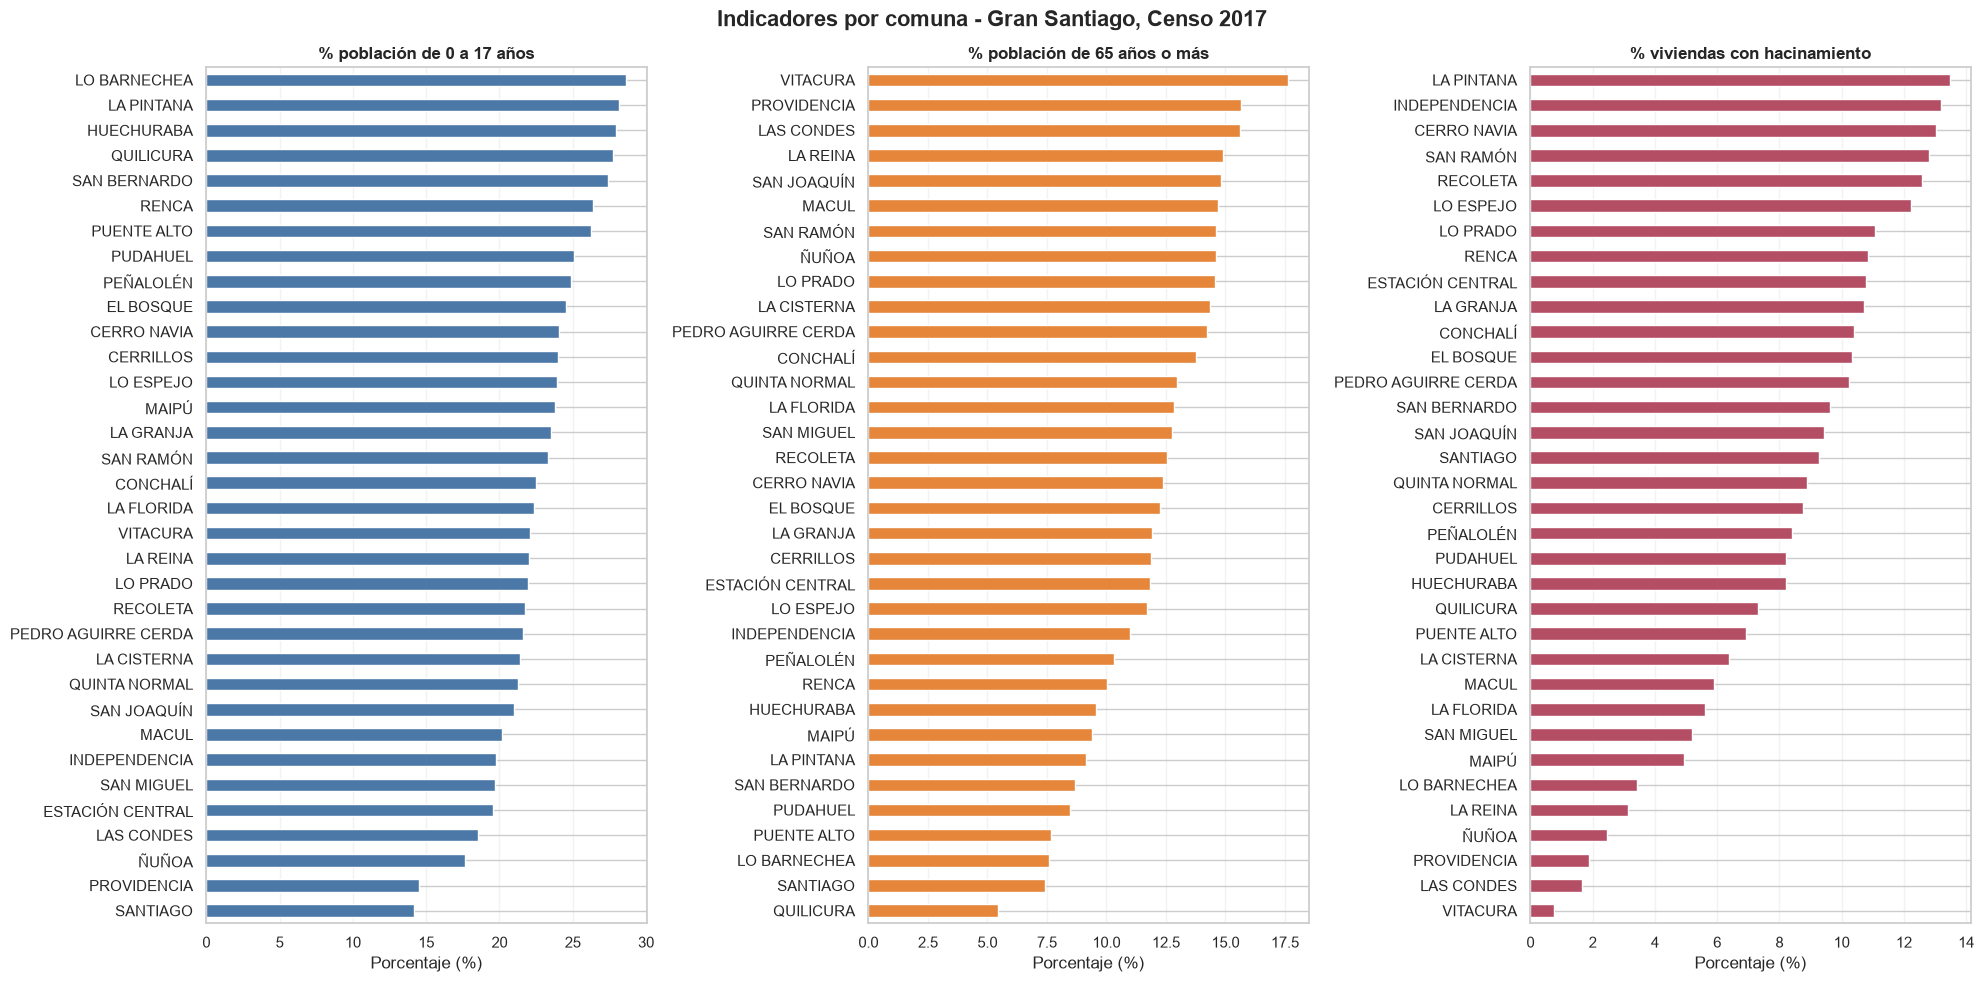

In [7]:
colors = {"pct_0_17": "#4C78A8", "pct_65_mas": "#E6863B", "pct_hacinamiento": "#B44E64"}
labels = {
    "pct_0_17": "% población de 0 a 17 años",
    "pct_65_mas": "% población de 65 años o más",
    "pct_hacinamiento": "% viviendas con hacinamiento",
}

fig, axes = plt.subplots(1, 3, figsize=(20, 10))
for ax, indicator in zip(axes, indicadores):
    ordered = gdf_comuna.set_index("nom_comuna")[indicator].sort_values()
    ordered.plot.barh(ax=ax, color=colors[indicator])
    ax.set_title(labels[indicator], fontweight="bold")
    ax.set_xlabel("Porcentaje (%)")
    ax.set_ylabel("")
    ax.grid(axis="x", alpha=.25)
fig.suptitle("Indicadores por comuna - Gran Santiago, Censo 2017", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

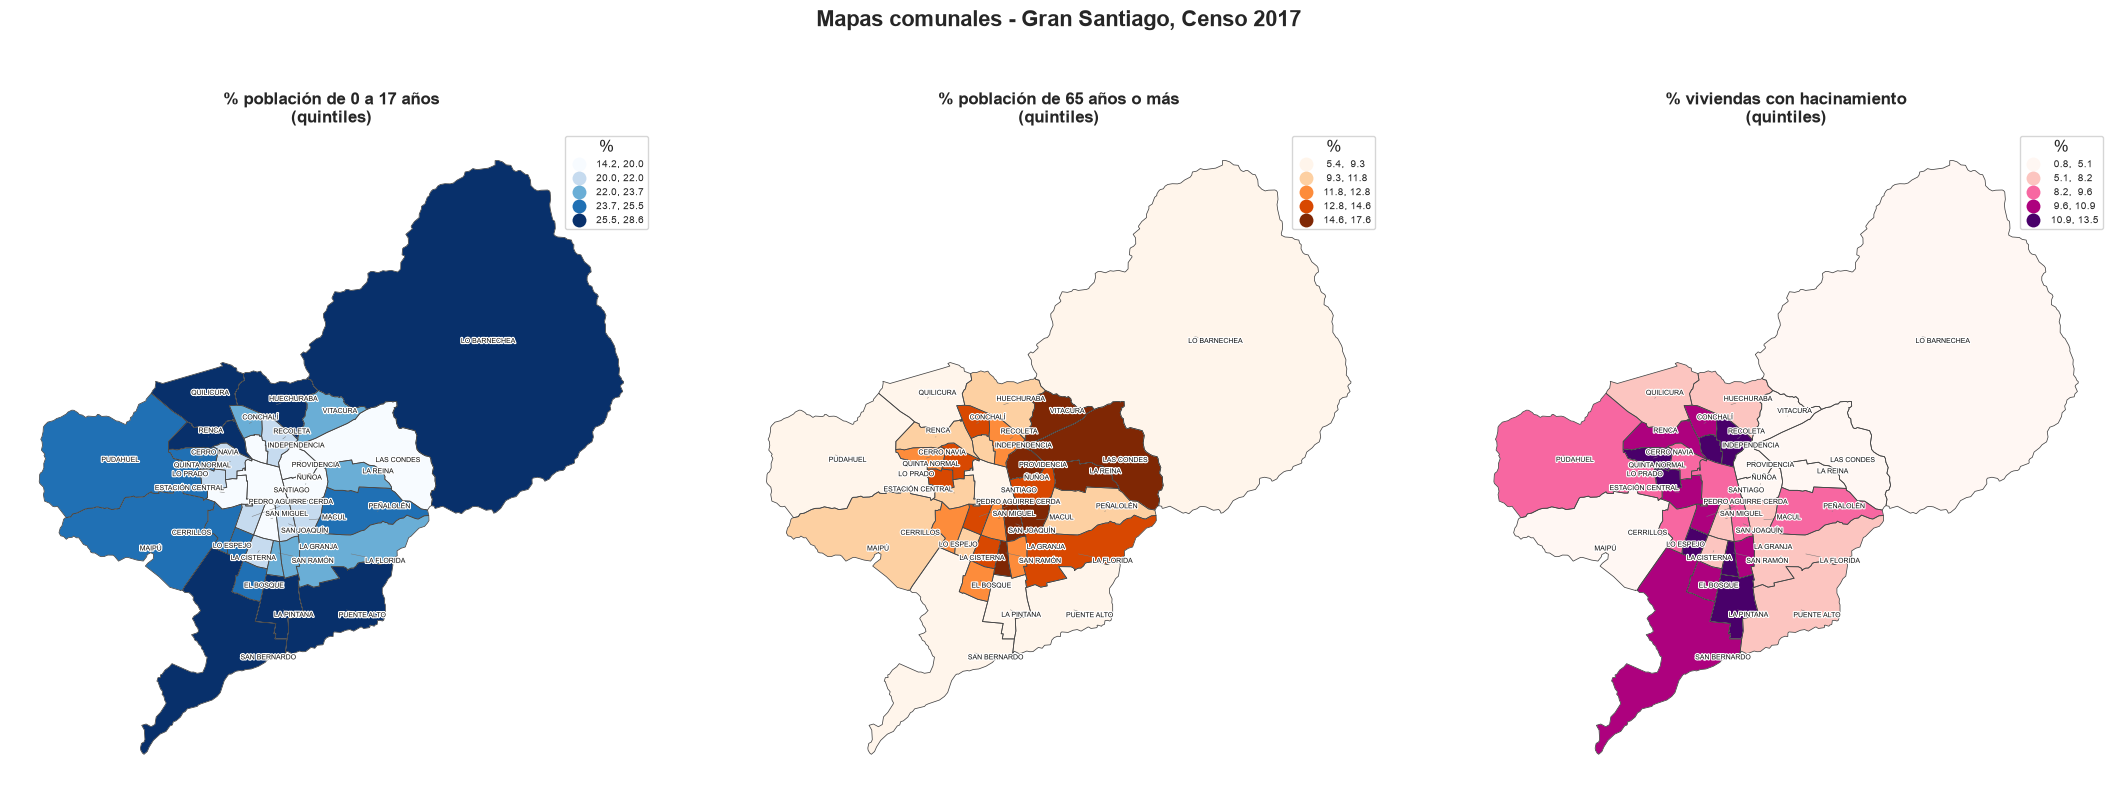

In [8]:
def classification_for(series, k=5):
    clean = series.dropna()
    quantile_classes = pd.qcut(clean, q=k, duplicates="drop").cat.categories.size
    if quantile_classes == k:
        return "quantiles", k, "quintiles"
    return "equal_interval", min(k, clean.nunique()), "intervalos iguales"

def plot_map(ax, frame, indicator, cmap, title, labels_on=False, boundary=None):
    scheme, k, scheme_label = classification_for(frame[indicator])
    frame.plot(
        column=indicator, cmap=cmap, scheme=scheme, k=k,
        legend=True, legend_kwds={"title": "%", "fmt": "{:.1f}", "fontsize": 7},
        edgecolor="white", linewidth=.25, ax=ax
    )
    if boundary is not None:
        boundary.boundary.plot(ax=ax, color="#333333", linewidth=.65)
    else:
        frame.boundary.plot(ax=ax, color="#444444", linewidth=.55)
    if labels_on:
        points = frame.geometry.representative_point()
        texts = [
            ax.text(point.x, point.y, name, fontsize=5, ha="center", va="center",
                    color="#111111", path_effects=[pe.withStroke(linewidth=1.7, foreground="white")])
            for point, name in zip(points, frame["nom_comuna"])
        ]
        adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="#777", lw=.35))
    ax.set_title(f"{title}\n({scheme_label})", fontweight="bold")
    ax.axis("off")
    return scheme_label

fig, axes = plt.subplots(1, 3, figsize=(22, 8))
plot_map(axes[0], gdf_comuna, "pct_0_17", "Blues", labels["pct_0_17"], labels_on=True)
plot_map(axes[1], gdf_comuna, "pct_65_mas", "Oranges", labels["pct_65_mas"], labels_on=True)
plot_map(axes[2], gdf_comuna, "pct_hacinamiento", "RdPu", labels["pct_hacinamiento"], labels_on=True)
fig.suptitle("Mapas comunales - Gran Santiago, Censo 2017", fontsize=16, fontweight="bold", y=.99)
plt.tight_layout(rect=[0, 0, 1, .91])
plt.show()

### 7.1 Lectura de los resultados comunales

Los resultados muestran contrastes claros. La población de 0 a 17 años varía entre **14,18% y 28,60%**: Lo Barnechea, La Pintana, Huechuraba, Quilicura y San Bernardo presentan los valores más altos; Santiago, Providencia, Ñuñoa y Las Condes se ubican entre los más bajos. Lo Barnechea es una excepción importante: combina una proporción infantil alta con hacinamiento muy bajo, por lo que edad y precariedad no deben confundirse.

La población de 65 años o más varía entre **5,44% y 17,61%**. Vitacura, Providencia, Las Condes y La Reina muestran valores altos, mientras Quilicura, Santiago, Lo Barnechea, Puente Alto y Pudahuel presentan valores menores. En términos generales aparece una mayor presencia relativa de personas mayores en el oriente y centro-oriente, frente a estructuras más jóvenes en varias comunas periféricas, aunque no es un patrón uniforme.

El hacinamiento varía entre **0,75% y 13,47%**. Los porcentajes más altos se observan en La Pintana, Independencia, Cerro Navia, San Ramón y Recoleta; los más bajos, en Vitacura, Las Condes, Providencia, Ñuñoa y La Reina. La distribución no forma un gradiente simple: combina focos del norte, norponiente, centro-norte y sur de la ciudad.

## 8. Indicadores a nivel de zona censal urbana

Se repite la lógica anterior agrupando por `z.geocodigo`. El identificador se mantiene como texto en la tabla de resultados y solo se convierte a número para enlazar con la cartografía. El filtro `shp.urbano = 1` se aplica a la geometría oficial.

In [9]:
sql_zona = r'''
WITH area AS (
    SELECT c.codigo_comuna, c.nom_comuna
    FROM public.comunas c
    JOIN public.provincias pr USING (provincia_ref_id)
    WHERE pr.nom_provincia = 'SANTIAGO'
       OR c.nom_comuna IN ('PUENTE ALTO', 'SAN BERNARDO')
),
personas_zona AS (
    SELECT z.geocodigo, a.nom_comuna,
           COUNT(*) AS n_personas,
           COUNT(*) FILTER (WHERE p.p09 BETWEEN 0 AND 100) AS n_edad_valida,
           ROUND((100.0 * COUNT(*) FILTER (WHERE p.p09 BETWEEN 0 AND 17)
               / NULLIF(COUNT(*) FILTER (WHERE p.p09 BETWEEN 0 AND 100), 0))::numeric, 2)::double precision AS pct_0_17,
           ROUND((100.0 * COUNT(*) FILTER (WHERE p.p09 BETWEEN 65 AND 100)
               / NULLIF(COUNT(*) FILTER (WHERE p.p09 BETWEEN 0 AND 100), 0))::numeric, 2)::double precision AS pct_65_mas
    FROM public.personas p
    JOIN public.hogares h USING (hogar_ref_id)
    JOIN public.viviendas v USING (vivienda_ref_id)
    JOIN public.zonas z USING (zonaloc_ref_id)
    JOIN area a USING (codigo_comuna)
    GROUP BY z.geocodigo, a.nom_comuna
),
viviendas_zona AS (
    SELECT z.geocodigo,
           COUNT(*) FILTER (
               WHERE v.p01 BETWEEN 1 AND 7 AND v.p02 = 1
                 AND v.ind_hacin_rec BETWEEN 1 AND 4
           ) AS n_viviendas_validas,
           COUNT(*) FILTER (
               WHERE v.p01 BETWEEN 1 AND 7 AND v.p02 = 1
                 AND v.ind_hacin_rec BETWEEN 2 AND 4
           ) AS n_viviendas_hacinadas,
           ROUND((100.0 * COUNT(*) FILTER (
               WHERE v.p01 BETWEEN 1 AND 7 AND v.p02 = 1
                 AND v.ind_hacin_rec BETWEEN 2 AND 4)
               / NULLIF(COUNT(*) FILTER (
                   WHERE v.p01 BETWEEN 1 AND 7 AND v.p02 = 1
                     AND v.ind_hacin_rec BETWEEN 1 AND 4), 0))::numeric, 2)::double precision AS pct_hacinamiento
    FROM public.viviendas v
    JOIN public.zonas z USING (zonaloc_ref_id)
    JOIN area a USING (codigo_comuna)
    GROUP BY z.geocodigo
)
SELECT p.geocodigo, p.nom_comuna, shp.geom,
       p.n_personas, p.n_edad_valida, p.pct_0_17, p.pct_65_mas,
       v.n_viviendas_validas, v.n_viviendas_hacinadas, v.pct_hacinamiento
FROM personas_zona p
JOIN viviendas_zona v USING (geocodigo)
JOIN dpa.zonas_censales_rm shp
  ON shp.geocodigo = p.geocodigo::double precision
WHERE shp.urbano = 1
ORDER BY p.nom_comuna, p.geocodigo;
'''

gdf_zona = gpd.read_postgis(sql_zona, engine, geom_col="geom")
cartographic_zones = pd.read_sql('''
    WITH area AS (
        SELECT c.nom_comuna
        FROM comunas c JOIN provincias pr USING (provincia_ref_id)
        WHERE pr.nom_provincia='SANTIAGO'
           OR c.nom_comuna IN ('PUENTE ALTO','SAN BERNARDO')
    )
    SELECT shp.geocodigo::bigint::text AS geocodigo,
           shp.nom_comuna, shp.nom_zona
    FROM dpa.zonas_censales_rm shp
    JOIN area a ON UPPER(shp.nom_comuna)=a.nom_comuna
    WHERE shp.urbano=1
    ORDER BY shp.geocodigo
''', engine)
zones_without_data = cartographic_zones.loc[
    ~cartographic_zones["geocodigo"].isin(gdf_zona["geocodigo"])
]

assert len(cartographic_zones) == 1644
assert len(zones_without_data) == 1
assert len(gdf_zona) == len(cartographic_zones) - len(zones_without_data)
assert gdf_zona["geocodigo"].is_unique
assert gdf_zona[indicadores].notna().all(axis=None)
assert gdf_zona[indicadores].apply(lambda s: s.between(0, 100).all()).all()
assert (gdf_zona["n_personas"] == gdf_zona["n_edad_valida"]).all()
assert gdf_zona.crs.to_epsg() == 32719 and gdf_zona.geometry.is_valid.all()

print(f"Zonas censales urbanas obtenidas: {len(gdf_zona)}")
print(f"Geometrías urbanas del área: {len(cartographic_zones)}; sin registros censales enlazables: {len(zones_without_data)}")
display(zones_without_data)
print(f"CRS: {gdf_zona.crs}; duplicados: {gdf_zona.geocodigo.duplicated().sum()}; geometrías inválidas: {(~gdf_zona.geometry.is_valid).sum()}")
display(gdf_zona.drop(columns="geom").head(10).round(2))

Zonas censales urbanas obtenidas: 1643
Geometrías urbanas del área: 1644; sin registros censales enlazables: 1


,geocodigo,nom_comuna,nom_zona
1422,13132031003,VITACURA,VITACURA


CRS: EPSG:32719; duplicados: 0; geometrías inválidas: 0


,geocodigo,nom_comuna,n_personas,n_edad_valida,pct_0_17,pct_65_mas,n_viviendas_validas,n_viviendas_hacinadas,pct_hacinamiento
0,13102011001,CERRILLOS,2520,2520,21.15,19.29,790,6,0.76
1,13102011002,CERRILLOS,3353,3353,20.79,13.03,929,184,19.81
2,13102011003,CERRILLOS,4648,4648,32.59,4.09,1283,39,3.04
3,13102011004,CERRILLOS,5609,5609,32.86,3.32,1593,50,3.14
4,13102021001,CERRILLOS,2850,2850,20.60,17.54,923,55,5.96
5,13102021002,CERRILLOS,3877,3877,21.20,15.97,1175,72,6.13
6,13102021003,CERRILLOS,2377,2377,17.50,21.20,621,23,3.70
7,13102021004,CERRILLOS,2660,2660,20.30,17.74,816,30,3.68
8,13102031001,CERRILLOS,5765,5765,28.67,6.40,1443,180,12.47
9,13102031002,CERRILLOS,4343,4343,21.87,16.00,1240,147,11.85


In [10]:
print("Estadísticos descriptivos por zona censal")
display(gdf_zona[indicadores].describe().round(2))

print("Extremos con denominadores mínimos de presentación: 100 personas o 30 viviendas válidas.")
for indicator in indicadores:
    if indicator == "pct_hacinamiento":
        denominator, minimum = "n_viviendas_validas", 30
    else:
        denominator, minimum = "n_edad_valida", 100
    print(f"Valores altos y bajos: {indicator}")
    display(extremos(
        gdf_zona, indicator, ["geocodigo", "nom_comuna"], denominator,
        minimum=minimum
    ).round(2))

Estadísticos descriptivos por zona censal


,pct_0_17,pct_65_mas,pct_hacinamiento
count,1643.00,1643.00,1643.00
mean,22.02,11.59,7.74
std,5.61,5.15,5.27
min,0.00,0.00,0.00
25%,18.92,7.32,3.08
50%,21.79,12.09,7.32
75%,25.22,15.28,11.74
max,42.24,29.10,53.33


Extremos con denominadores mínimos de presentación: 100 personas o 30 viviendas válidas.
Valores altos y bajos: pct_0_17


,extremo,geocodigo,nom_comuna,pct_0_17,n_edad_valida
1539,Bajo,13101221001,SANTIAGO,2.34,11031
1248,Bajo,13128021005,RENCA,3.68,163
917,Bajo,13123081004,PROVIDENCIA,5.98,1922
1429,Bajo,13101011003,SANTIAGO,6.56,2209
867,Bajo,13123011001,PROVIDENCIA,6.58,2142
553,Alto,13115011011,LO BARNECHEA,42.24,4261
1015,Alto,13201051004,PUENTE ALTO,39.85,542
459,Alto,13113071005,LA REINA,39.66,4987
56,Alto,13103091005,CERRO NAVIA,36.93,4771
548,Alto,13115011006,LO BARNECHEA,36.35,4823


Valores altos y bajos: pct_65_mas


,extremo,geocodigo,nom_comuna,pct_65_mas,n_edad_valida
459,Bajo,13113071005,LA REINA,1.00,4987
56,Bajo,13103091005,CERRO NAVIA,1.05,4771
1248,Bajo,13128021005,RENCA,1.23,163
1440,Bajo,13101031001,SANTIAGO,1.30,2313
553,Bajo,13115011011,LO BARNECHEA,1.46,4261
1560,Alto,13132011005,VITACURA,29.10,2708
1334,Alto,13401101004,SAN BERNARDO,26.00,1773
1602,Alto,13120041003,ÑUÑOA,24.86,3045
890,Alto,13123031009,PROVIDENCIA,24.82,3142
671,Alto,13119031003,MAIPÚ,24.63,2867


Valores altos y bajos: pct_hacinamiento


,extremo,geocodigo,nom_comuna,pct_hacinamiento,n_viviendas_validas
549,Bajo,13115011007,LO BARNECHEA,0.10,1004
551,Bajo,13115011009,LO BARNECHEA,0.11,893
543,Bajo,13115011001,LO BARNECHEA,0.18,1122
538,Bajo,13114151003,LAS CONDES,0.19,1053
450,Bajo,13113051003,LA REINA,0.21,934
145,Alto,13106051003,ESTACIÓN CENTRAL,24.07,619
1198,Alto,13127021001,RECOLETA,23.74,1563
1151,Alto,13125031001,QUILICURA,22.45,196
143,Alto,13106051001,ESTACIÓN CENTRAL,22.32,811
1140,Alto,13125021011,QUILICURA,21.95,852


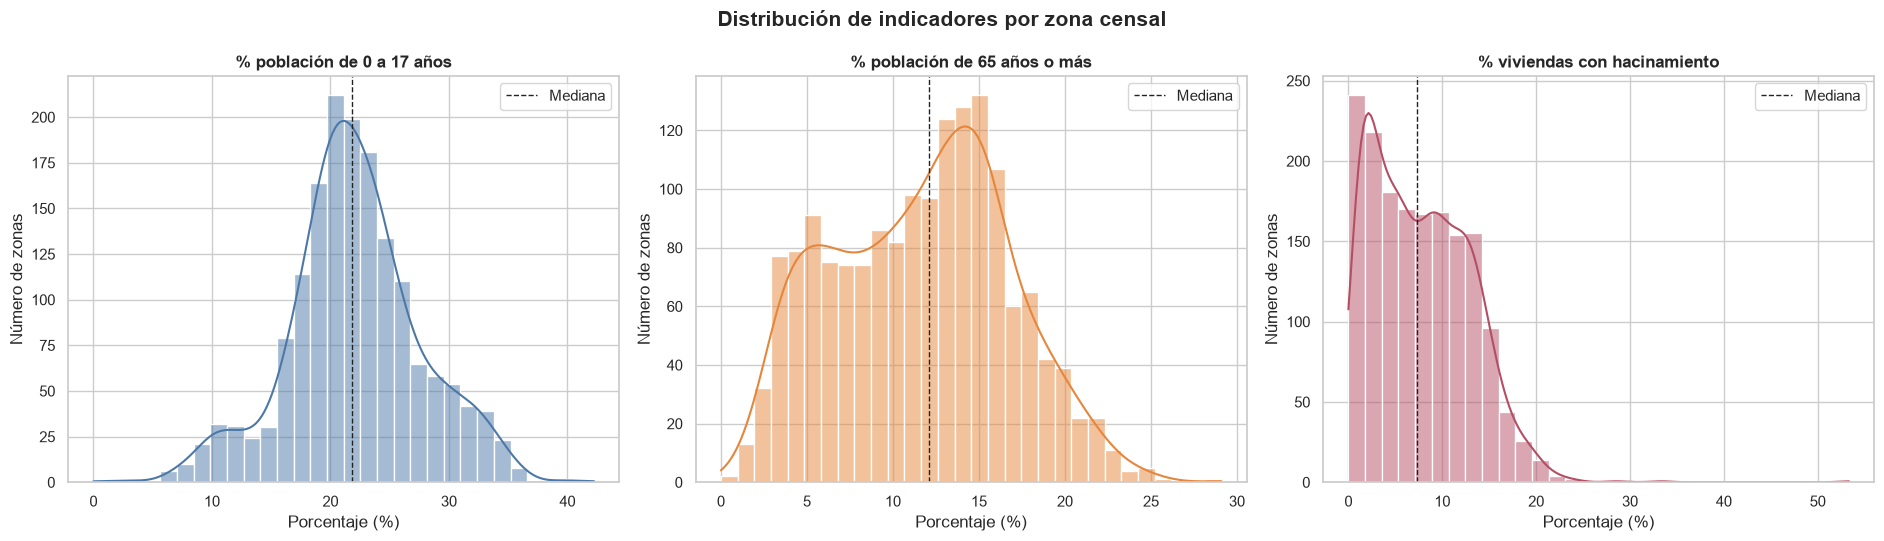

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))
for ax, indicator in zip(axes, indicadores):
    sns.histplot(gdf_zona[indicator], bins=30, kde=True, color=colors[indicator], ax=ax)
    ax.axvline(gdf_zona[indicator].median(), color="#222", ls="--", lw=1, label="Mediana")
    ax.set_title(labels[indicator], fontweight="bold")
    ax.set_xlabel("Porcentaje (%)")
    ax.set_ylabel("Número de zonas")
    ax.legend()
fig.suptitle("Distribución de indicadores por zona censal", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

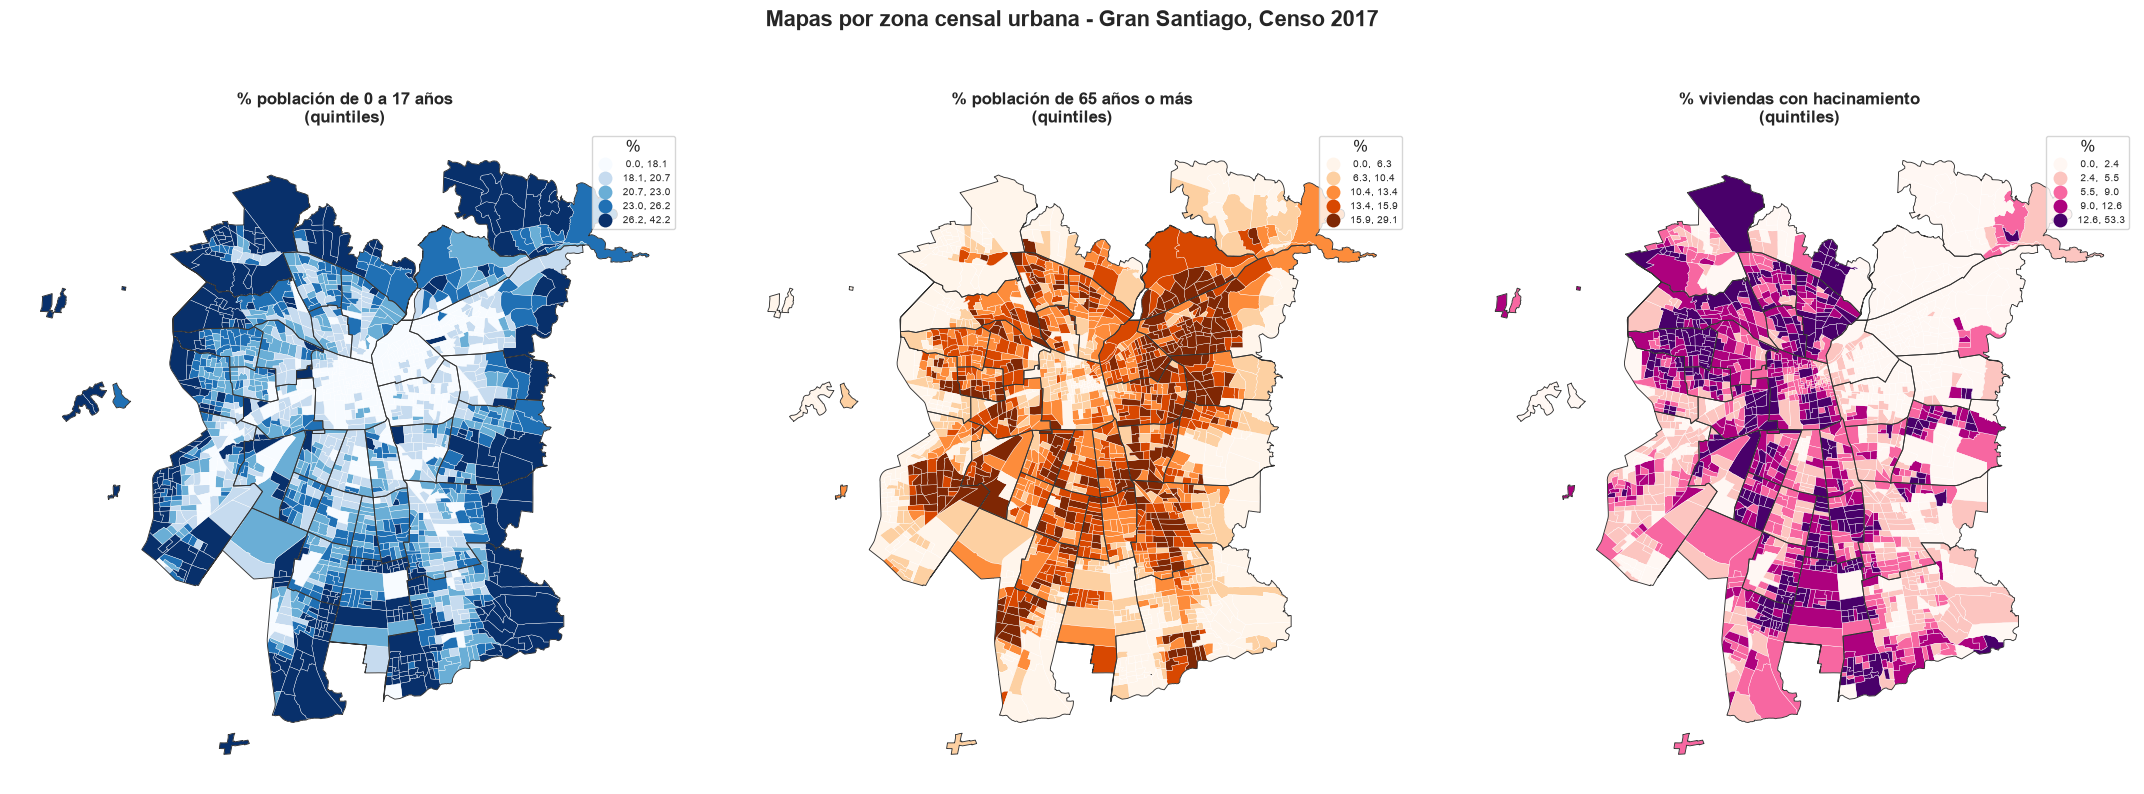

In [12]:
urban_footprint = gdf_zona.geometry.union_all()
comunas_urbanas = gpd.clip(gdf_comuna[["nom_comuna", "geom"]], urban_footprint)

fig, axes = plt.subplots(1, 3, figsize=(22, 8))
plot_map(axes[0], gdf_zona, "pct_0_17", "Blues", labels["pct_0_17"], boundary=comunas_urbanas)
plot_map(axes[1], gdf_zona, "pct_65_mas", "Oranges", labels["pct_65_mas"], boundary=comunas_urbanas)
plot_map(axes[2], gdf_zona, "pct_hacinamiento", "RdPu", labels["pct_hacinamiento"], boundary=comunas_urbanas)
fig.suptitle("Mapas por zona censal urbana - Gran Santiago, Censo 2017", fontsize=16, fontweight="bold", y=.99)
plt.tight_layout(rect=[0, 0, 1, .91])
plt.show()

### 8.1 Lectura de los resultados por zona censal

La cartografía contiene 1.644 zonas urbanas en el área, pero `13132031003` (Vitacura) no tiene personas ni viviendas enlazables en las tablas del respaldo; se excluye por carecer de denominador. Las **1.643 zonas analíticas** revelan una dispersión mayor que las comunas. El porcentaje de población de 0 a 17 años va de **0,00% a 42,24%**, el de 65 años o más de **0,00% a 29,10%**, y el hacinamiento de **0,00% a 53,33%**. Algunos extremos se apoyan en denominadores muy pequeños -por ejemplo, una zona de Renca llega a 53,33% con solo 15 viviendas válidas-, por lo que las tablas de presentación exigen al menos 100 personas o 30 viviendas, sin alterar mapas, descriptivos ni correlaciones.

Entre los extremos con denominadores sustantivos, la zona `13115011011` de Lo Barnechea alcanza 42,24% de población de 0 a 17 años; la zona `13132011005` de Vitacura llega a 29,10% de población de 65 años o más. Para hacinamiento destacan `13106051003` de Estación Central (24,07%; 619 viviendas válidas) y `13127021001` de Recoleta (23,74%; 1.563 viviendas válidas).

Los mapas muestran mosaicos internos: comunas con promedios similares contienen zonas de distinto perfil, y algunos focos cruzan límites comunales. Esta heterogeneidad es precisamente la información que el promedio comunal suaviza.

## 9. Relación entre indicadores y comparación multiescalar

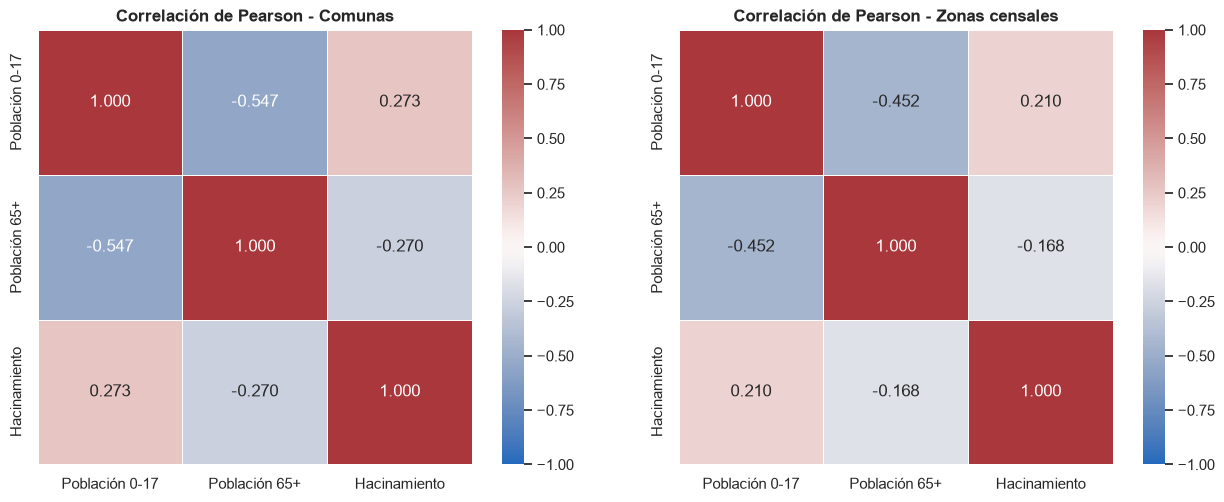

,Relación,Comuna,Zona censal
0,0-17 vs. 65+,-0.5468,-0.4515
1,0-17 vs. hacinamiento,0.2728,0.2103
2,65+ vs. hacinamiento,-0.2696,-0.1679


In [13]:
corr_comuna = gdf_comuna[indicadores].corr()
corr_zona = gdf_zona[indicadores].corr()
short_labels = ["Población 0-17", "Población 65+", "Hacinamiento"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, matrix, title in [
    (axes[0], corr_comuna, "Comunas"),
    (axes[1], corr_zona, "Zonas censales"),
]:
    sns.heatmap(matrix, annot=True, fmt=".3f", cmap="vlag", vmin=-1, vmax=1,
                square=True, linewidths=.5, ax=ax,
                xticklabels=short_labels, yticklabels=short_labels)
    ax.set_title(f"Correlación de Pearson - {title}", fontweight="bold")
plt.tight_layout()
plt.show()

corr_comparison = pd.DataFrame({
    "Relación": ["0-17 vs. 65+", "0-17 vs. hacinamiento", "65+ vs. hacinamiento"],
    "Comuna": [corr_comuna.loc["pct_0_17", "pct_65_mas"],
               corr_comuna.loc["pct_0_17", "pct_hacinamiento"],
               corr_comuna.loc["pct_65_mas", "pct_hacinamiento"]],
    "Zona censal": [corr_zona.loc["pct_0_17", "pct_65_mas"],
                    corr_zona.loc["pct_0_17", "pct_hacinamiento"],
                    corr_zona.loc["pct_65_mas", "pct_hacinamiento"]],
})
display(corr_comparison.round(4))

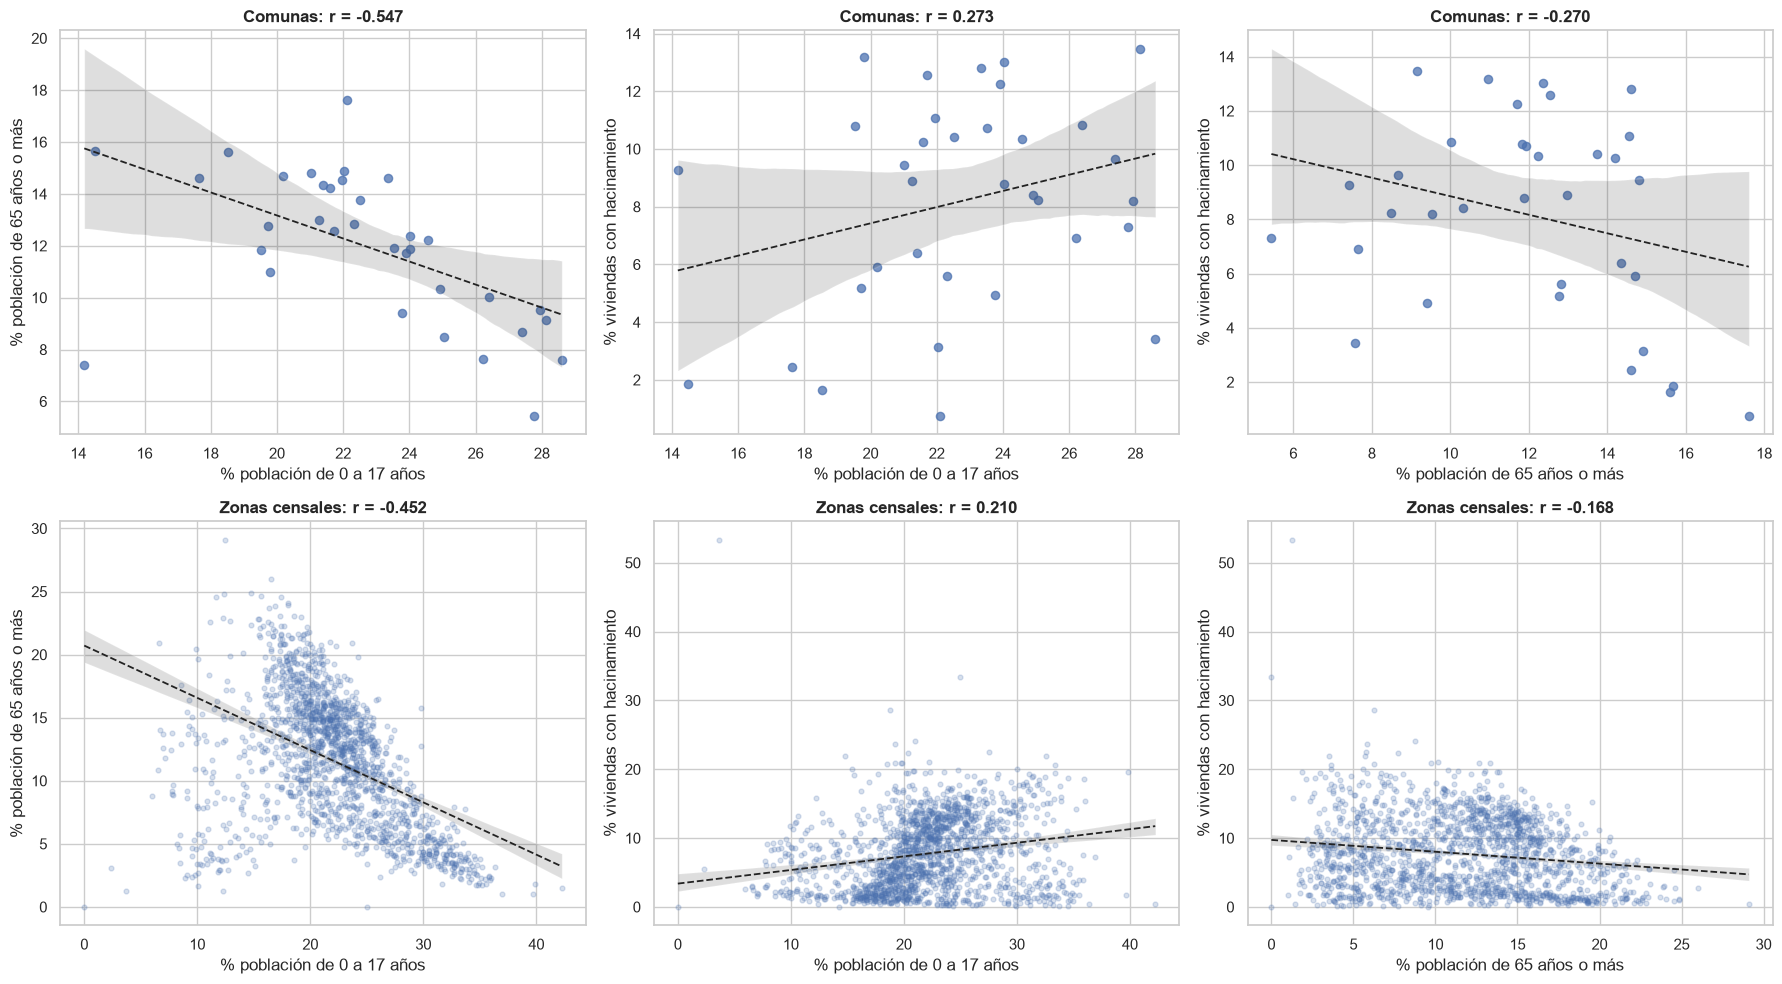

In [14]:
pairs = [
    ("pct_0_17", "pct_65_mas"),
    ("pct_0_17", "pct_hacinamiento"),
    ("pct_65_mas", "pct_hacinamiento"),
]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for row, (frame, level) in enumerate([(gdf_comuna, "Comunas"), (gdf_zona, "Zonas censales")]):
    for col, (x, y) in enumerate(pairs):
        ax = axes[row, col]
        sns.regplot(
            data=frame, x=x, y=y, ax=ax,
            scatter_kws={"alpha": .75 if row == 0 else .22, "s": 35 if row == 0 else 12},
            line_kws={"color": "#222222", "ls": "--", "lw": 1.3}
        )
        r = frame[[x, y]].corr().iloc[0, 1]
        ax.set_title(f"{level}: r = {r:.3f}", fontweight="bold")
        ax.set_xlabel(labels[x])
        ax.set_ylabel(labels[y])
plt.tight_layout()
plt.show()

In [15]:
within = gdf_zona.groupby("nom_comuna")[indicadores].agg(["min", "max", "std"])
for indicator in indicadores:
    within[(indicator, "rango")] = within[(indicator, "max")] - within[(indicator, "min")]

within_summary = pd.DataFrame({
    "rango_0_17": within[("pct_0_17", "rango")],
    "rango_65_mas": within[("pct_65_mas", "rango")],
    "rango_hacinamiento": within[("pct_hacinamiento", "rango")],
    "sd_0_17": within[("pct_0_17", "std")],
    "sd_65_mas": within[("pct_65_mas", "std")],
    "sd_hacinamiento": within[("pct_hacinamiento", "std")],
}).sort_values("rango_hacinamiento", ascending=False)

print("Comunas con mayor rango interno entre zonas (los extremos pueden incluir denominadores pequeños)")
display(within_summary.head(10).round(2))

Comunas con mayor rango interno entre zonas (los extremos pueden incluir denominadores pequeños)


,rango_0_17,rango_65_mas,rango_hacinamiento,sd_0_17,sd_65_mas,sd_hacinamiento
nom_comuna,,,,,,
RENCA,32.17,18.76,49.78,5.61,5.22,7.28
CONCHALÍ,7.80,21.53,29.04,2.07,3.94,5.11
ESTACIÓN CENTRAL,21.98,19.78,23.29,4.01,5.11,6.14
LO ESPEJO,14.25,10.72,21.99,2.87,2.41,4.14
QUILICURA,15.78,15.81,21.62,4.17,3.41,5.29
PUENTE ALTO,25.56,19.14,20.58,5.34,4.48,4.69
LA PINTANA,36.01,16.13,19.33,5.47,4.19,3.58
RECOLETA,16.21,13.78,19.21,3.24,3.08,4.32
CERRILLOS,17.10,17.88,19.05,5.09,5.86,5.35


### 9.1 Interpretación de las correlaciones

La relación entre los dos indicadores etarios es **negativa moderada**: $r=-0,547$ en comunas y $r=-0,452$ en zonas censales. Parte de esa relación inversa es composicional, porque ambas proporciones dividen por la misma población y compiten con el grupo de 18 a 64 años; no debe interpretarse como una relación causal entre personas jóvenes y mayores.

La relación entre población de 0 a 17 años y hacinamiento es **positiva débil** ($r=0,273$ comunal; $r=0,210$ zonal). Entre población de 65 años o más y hacinamiento es **negativa débil** ($r=-0,270$ comunal; $r=-0,168$ zonal). Una asociación débil sigue siendo un resultado válido: indica que la estructura etaria, por sí sola, explica poco de la variación territorial del hacinamiento.

Los coeficientes cambian al modificar la escala. Esta sensibilidad ilustra el **problema de la unidad espacial modificable (MAUP)**: agregar microdatos en límites y tamaños territoriales distintos puede cambiar la magnitud de una relación. Ninguna correlación implica causalidad.

## 10. Discusión territorial y limitaciones

Los resultados son compatibles con una metrópolis social y demográficamente fragmentada, pero no con una división espacial única. Varias comunas periféricas presentan estructuras más jóvenes; el oriente y centro-oriente concentran proporciones mayores de población de 65 años o más y bajos niveles de hacinamiento. Sin embargo, Lo Barnechea combina alta proporción infantil con muy poco hacinamiento, y los focos altos de hacinamiento aparecen en sectores distintos de la ciudad. Estas excepciones muestran que una misma estructura etaria puede coexistir con condiciones habitacionales muy diferentes.

La escala zonal hace visibles contrastes internos y valores extremos. También aumenta la inestabilidad de porcentajes cuando el denominador es pequeño. Por eso el notebook conserva y muestra los denominadores, y usa umbrales solo para las tablas de extremos, no para eliminar observaciones del análisis.

Limitaciones principales:

- El Censo 2017 es una medición transversal y abreviada; los resultados no describen necesariamente la situación actual.
- El análisis es ecológico: una asociación territorial no autoriza inferencias sobre individuos u hogares.
- Las correlaciones no controlan ingresos, migración, tipo de vivienda, composición del hogar u otros factores.
- El MAUP y los denominadores pequeños influyen en la comparación entre escalas.
- El indicador de hacinamiento usa la recodificación incluida en la base del curso y un universo de viviendas; no comparte denominador con los indicadores de personas.

La literatura de CEPAL sobre Santiago documenta la fragmentación y la segregación residencial de la metrópolis; aquí se usa como contexto interpretativo y no como prueba causal de los patrones específicos observados.

## 11. Conclusiones

Los tres indicadores fueron calculados correctamente para **34 comunas y 1.643 zonas censales urbanas**. La escala comunal resume patrones generales de envejecimiento, juventud y condiciones habitacionales; la zona censal revela heterogeneidad interna y extremos que esos promedios ocultan.

La asociación inversa entre las proporciones de población joven y mayor es moderada y parcialmente composicional. Las asociaciones del hacinamiento con la estructura etaria son débiles y cambian con la escala. Por tanto, los resultados apoyan una lectura territorial multiescalar y prudente: describen desigualdades espaciales, pero no demuestran relaciones causales ni individuales.

## 12. Bibliografía y fuentes

- Instituto Nacional de Estadísticas (INE). (2018). *Memoria del Censo 2017*. [PDF oficial](https://www.ine.gob.cl/docs/default-source/censo-de-poblacion-y-vivienda/publicaciones-y-anuarios/2017/memoria-del-censo-2017/libro_memoria_censal_2017_final.pdf).
- Instituto Nacional de Estadísticas (INE). (2018). *INE pone a disposición la base de microdatos del Censo 2017*. [Sitio oficial](https://www.ine.gob.cl/sala-de-prensa/prensa/general/noticia/2019/09/16/ine-pone-a-disposici%C3%B3n-la-base-de-microdatos-del-censo-2017).
- Ministerio de Desarrollo Social. (2015). *Nueva metodología de medición de la pobreza por ingresos y multidimensional*. [Documento oficial](https://observatorio.ministeriodesarrollosocial.gob.cl/storage/docs/casen/2013/Nueva_Metodologia_de_Medicion_de_Pobreza.pdf).
- Rodríguez Vignoli, J., & Rowe, F. (2019). *Efectos cambiantes de la migración sobre el crecimiento, la estructura demográfica y la segregación residencial en ciudades grandes: el caso de Santiago, Chile, 1977-2017*. CEPAL, Serie Población y Desarrollo 125. [Ficha oficial](https://www.cepal.org/es/publicaciones/44367-efectos-cambiantes-la-migracion-crecimiento-la-estructura-demografica-la).
- CEPAL. (2020). *Descripción de los conceptos utilizados en el estudio del desplazamiento interno de la población: migración interna, movilidad cotidiana y segregación residencial*. [Sitio oficial](https://www.cepal.org/es/enfoques/descripcion-conceptos-utilizados-estudio-desplazamiento-interno-la-poblacion-migracion).
- Openshaw, S. (1984). Ecological fallacies and the analysis of areal census data. *Environment and Planning A, 16*(1), 17-31. [https://doi.org/10.1068/a160017](https://doi.org/10.1068/a160017).

**Diccionario de variables:** tablas `public.variables` y `public.variables_codificacion` incluidas en el respaldo `censo_rm_v2.backup` del curso.

In [16]:
print("Resumen final de validación")
print(f"- Comunas: {len(gdf_comuna)}")
print(f"- Zonas censales urbanas: {len(gdf_zona)}")
print(f"- Indicadores: {', '.join(indicadores)}")
print(f"- CRS común: {gdf_comuna.crs}")
print(f"- Duplicados territoriales: {gdf_comuna.codigo_comuna.duplicated().sum() + gdf_zona.geocodigo.duplicated().sum()}")
print(f"- Valores fuera de 0-100: {sum((~gdf_comuna[indicadores].apply(lambda s: s.between(0,100))).sum()) + sum((~gdf_zona[indicadores].apply(lambda s: s.between(0,100))).sum())}")
print(f"- Geometrías inválidas: {(~gdf_comuna.geometry.is_valid).sum() + (~gdf_zona.geometry.is_valid).sum()}")
print("Notebook validado de inicio a fin con la base del curso.")
engine.dispose()

Resumen final de validación
- Comunas: 34
- Zonas censales urbanas: 1643
- Indicadores: pct_0_17, pct_65_mas, pct_hacinamiento
- CRS común: EPSG:32719
- Duplicados territoriales: 0
- Valores fuera de 0-100: 0
- Geometrías inválidas: 0
Notebook validado de inicio a fin con la base del curso.
